In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from fraudguard.config import load_settings
from fraudguard.data.load import load_dataset
from fraudguard.data.split import temporal_split, transaction_day

settings = load_settings()
df = load_dataset(settings)
split = temporal_split(df, settings.split)

summary = pd.DataFrame(
    {
        name: {
            "rows": len(part),
            "frauds": int(part["isFraud"].sum()),
            "fraud_rate_%": round(part["isFraud"].mean() * 100, 2),
            "first_day": int(transaction_day(part).min()),
            "last_day": int(transaction_day(part).max()),
        }
        for name, part in split._asdict().items()
    }
).T
summary

Matplotlib is building the font cache; this may take a moment.


,rows,frauds,fraud_rate_%,first_day,last_day
train,410601.0,14419.0,3.51,1.0,119.0
valid,85303.0,2962.0,3.47,120.0,149.0
future,94636.0,3282.0,3.47,150.0,182.0


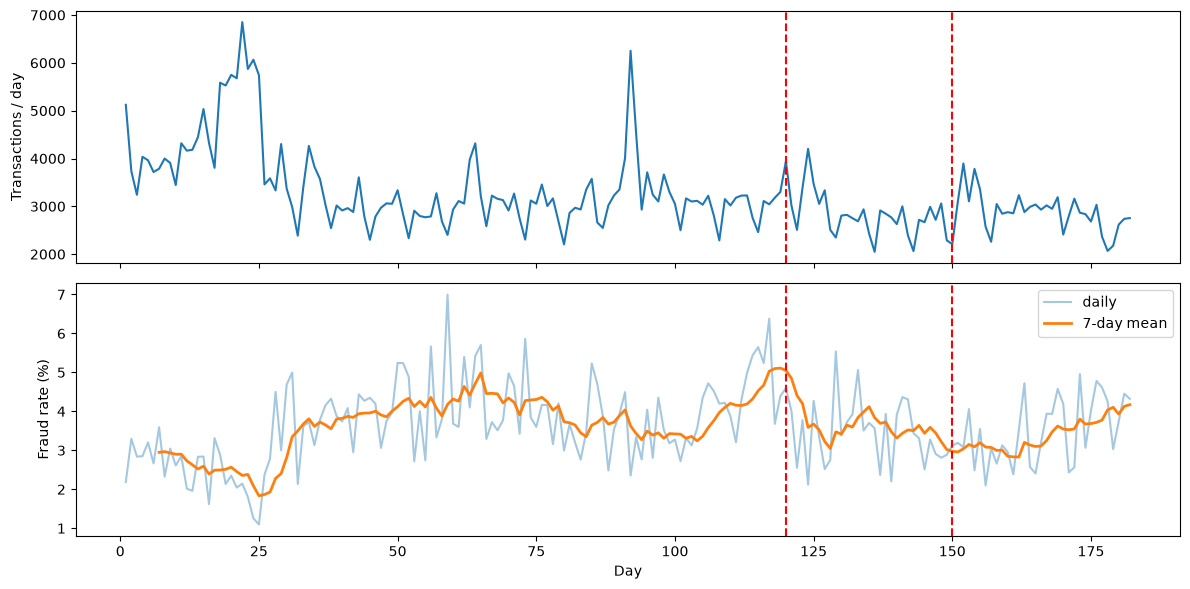

In [2]:
day = transaction_day(df)
daily = df.groupby(day).agg(n=("isFraud", "size"), fraud_rate=("isFraud", "mean"))

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].plot(daily.index, daily["n"])
axes[0].set_ylabel("Transactions / day")
axes[1].plot(daily.index, daily["fraud_rate"] * 100, alpha=0.4, label="daily")
axes[1].plot(
    daily.index, (daily["fraud_rate"] * 100).rolling(7).mean(), linewidth=2, label="7-day mean"
)
axes[1].set_ylabel("Fraud rate (%)")
axes[1].set_xlabel("Day")
axes[1].legend()
for ax in axes:
    for cut in (settings.split.train_end_day, settings.split.valid_end_day):
        ax.axvline(cut, color="red", linestyle="--")
plt.tight_layout()

,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
0,569877.0,134.511658,239.395081,0.251,43.970001,68.5,120.0,31937.390625
1,20663.0,149.244766,232.212158,0.292,35.043999,75.0,161.0,5191.000000


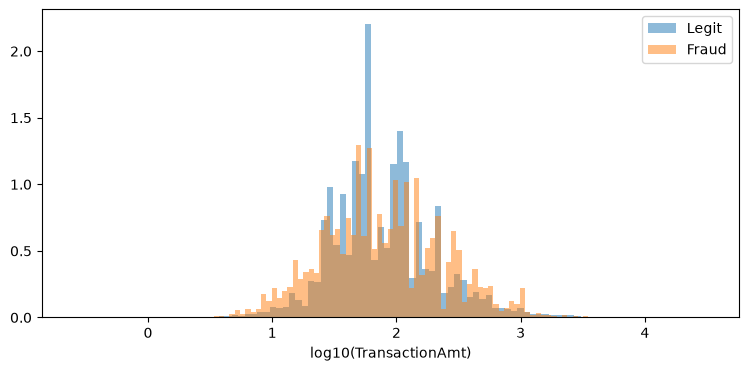

In [3]:
fig, ax = plt.subplots(figsize=(9, 4))
for label, name in [(0, "Legit"), (1, "Fraud")]:
    amounts = df.loc[df["isFraud"] == label, "TransactionAmt"]
    ax.hist(np.log10(amounts), bins=100, density=True, alpha=0.5, label=name)
ax.set_xlabel("log10(TransactionAmt)")
ax.legend()

df.groupby("isFraud")["TransactionAmt"].describe()

In [4]:
null_pct = df.isna().mean().sort_values(ascending=False)
print(f"Columns with >50% nulls: {(null_pct > 0.5).sum()} of {df.shape[1]}")
print(f"Columns with >90% nulls: {(null_pct > 0.9).sum()}")
null_pct.head(15)

Columns with >50% nulls: 214 of 434
Columns with >90% nulls: 12


id_24    0.991962
id_25    0.991310
id_07    0.991271
id_08    0.991271
id_21    0.991264
id_26    0.991257
id_27    0.991247
id_23    0.991247
id_22    0.991247
dist2    0.936284
D7       0.934099
id_18    0.923607
D13      0.895093
D14      0.894695
D12      0.890410
dtype: float64

In [5]:
id_cols = [c for c in df.columns if c.startswith("id_")]
has_identity = df[id_cols].notna().any(axis=1).rename("has_identity")
df.groupby(has_identity)["isFraud"].agg(rows="size", fraud_rate="mean")

,rows,fraud_rate
has_identity,,
False,446307,0.020939
True,144233,0.078470


In [6]:
df.groupby("ProductCD")["isFraud"].agg(rows="size", fraud_rate="mean").sort_values(
    "fraud_rate", ascending=False
)

,rows,fraud_rate
ProductCD,,
C,68519,0.116873
S,11628,0.058996
H,33024,0.047662
R,37699,0.037826
W,439670,0.020399


In [7]:
pd.crosstab(df["ProductCD"], has_identity, normalize="index").round(2)

has_identity,False,True
ProductCD,,
C,0.09,0.91
H,0.00,1.00
R,0.00,1.00
S,0.00,1.00
W,1.00,0.00


In [8]:
df[df["ProductCD"] == "C"].groupby(has_identity)["isFraud"].agg(rows="size", fraud_rate="mean")

,rows,fraud_rate
has_identity,,
False,6327,0.058163
True,62192,0.122845


## Conclusions

### Findings

1. **Temporal split is sound.** Train (days 1–119): 410,601 rows, 14,419 frauds. Valid (120–149): 85,303 rows, 2,962 frauds. Future (150–182): 94,636 rows, 3,282 frauds. The fraud rate is almost identical across sets (3.51% / 3.47% / 3.47%), so any drift will show up in the features, not in the label prior.
2. **The first month is atypical.** Volume peaks during the holiday season (days ~15–25, up to ~6,800 transactions/day) while the fraud rate stays low (~2–2.5%, dipping near 1%). After day ~28 the fraud rate moves to a 3.5–4.5% regime. A second volume spike around day 92 has no obvious explanation.
3. **Transaction amount alone is a weak signal.** Distributions overlap heavily. Fraud is somewhat shifted towards higher amounts (median 75 vs 68.5, 75th percentile 161 vs 120) and has more mass at very low amounts (< $10). Legit transactions show sharp peaks at recurring prices.
4. **Missing values are pervasive.** 214 of 434 columns have > 50% nulls; 12 have > 90%.
5. **Missingness is structural and informative.** Identity data is never present for product W, always present for H, R and S, and present for 91% of product C. Transactions with identity data have a much higher fraud rate (7.8% vs 2.1%), mostly because of the product mix. However, within product C, having identity data still doubles the fraud rate (12.3% vs 5.8%).
6. **Product type is strongly associated with fraud.** Product C: 11.7% fraud; W: 2.0% (and 74% of all transactions).

### Implications for modelling

- Use the temporal split everywhere; never random splits.
- Do not naively impute nulls: they carry signal. Tree models (LightGBM) can use NaN natively; linear models and SMOTE-based methods will need imputation **plus** missing-value indicators.
- Accuracy is meaningless at 3.5% prevalence; use PR-AUC, recall at fixed precision and a threshold chosen on the validation set.
- Hypothesis for the imbalance study (phase 3): compare training on all data vs down-weighting the holiday period.